已连接到 Python 3.8.10

数据总条数: 16666
时间范围: 0.00s 到 166.85s
采样间隔: 0.0100s


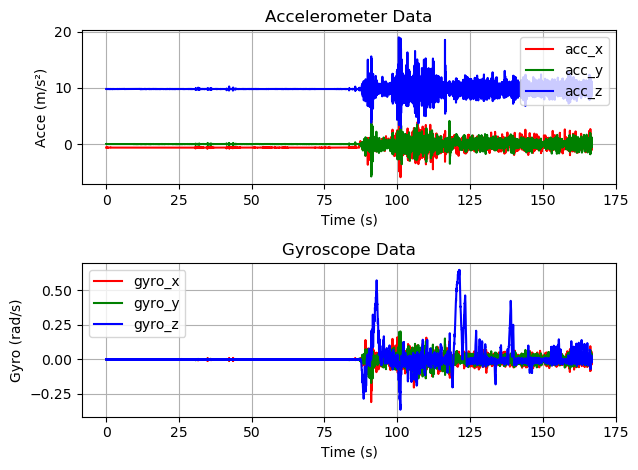

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

if __name__ == '__main__':

    timestamps = []
    gyro_x, gyro_y, gyro_z = [], [], []
    acc_x, acc_y, acc_z = [], [], []

    # 读取文件
    with open('../data/ch3/10_small.txt', 'r') as f:
        for line in f:
            # 只处理IMU数据行
            if line.startswith('IMU'):
                # 分割数据行
                data = line.split()
                # 提取时间戳和数据
                t = float(data[1])
                gx, gy, gz = float(data[2]), float(data[3]), float(data[4])
                ax, ay, az = float(data[5]), float(data[6]), float(data[7])
                
                # 存储数据
                timestamps.append(t)
                gyro_x.append(gx)
                gyro_y.append(gy)
                gyro_z.append(gz)
                acc_x.append(ax)
                acc_y.append(ay)
                acc_z.append(az)

    # 将所有列表转换为numpy数组
    timestamps = np.array(timestamps)
    gyro_x = np.array(gyro_x)
    gyro_y = np.array(gyro_y)
    gyro_z = np.array(gyro_z)
    acc_x = np.array(acc_x)
    acc_y = np.array(acc_y)
    acc_z = np.array(acc_z)
    
    # 计算相对时间
    relative_time = timestamps - timestamps[0]
    
    # 打印数据信息
    print(f"数据总条数: {len(relative_time)}")
    print(f"时间范围: {relative_time[0]:.2f}s 到 {relative_time[-1]:.2f}s")
    print(f"采样间隔: {np.mean(np.diff(relative_time)):.4f}s")
                
    plt.subplot(211)
    plt.plot(relative_time, acc_x, 'r')
    plt.plot(relative_time, acc_y, 'g')
    plt.plot(relative_time, acc_z, 'b')
    plt.xlabel('Time (s)')
    plt.ylabel('Acce (m/s²)')
    plt.title('Accelerometer Data')
    plt.legend(['acc_x','acc_y','acc_z'])
    plt.grid(True)
                
    plt.subplot(212)
    plt.plot(relative_time, gyro_x, 'r')
    plt.plot(relative_time, gyro_y, 'g')
    plt.plot(relative_time, gyro_z, 'b')
    plt.xlabel('Time (s)')
    plt.ylabel('Gyro (rad/s)')
    plt.title('Gyroscope Data')
    plt.legend(['gyro_x','gyro_y','gyro_z'])
    plt.grid(True)

    # 调整子图之间的间距
    plt.tight_layout()
    
    # 显示图片
    plt.show()
    exit(0)


In [ ]:
acc_x_sta = acc_x(75,0)
# mean_acce = np.array(np.mean(acc_x))